In [ ]:
!pip install tensorflow

C:\Users\chund\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.8857 - loss: 0.3967
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.9570 - loss: 0.1425
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9734 - loss: 0.0881
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9650 - loss: 0.1203

Test Accuracy: 0.9649999737739563
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


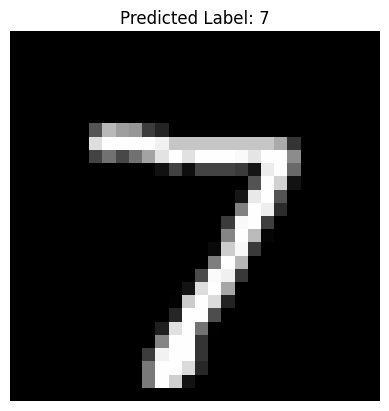

In [5]:
# IMAGE CLASSIFICATION USING CNN
# WORKING CODE FOR JUPYTER NOTEBOOK

# Step 1: Import Libraries
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense
import matplotlib.pyplot as plt
import numpy as np

# Step 2: Load Dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Step 3: Reduce Dataset Size (for low RAM systems)
X_train = X_train[:10000]
y_train = y_train[:10000]

X_test = X_test[:2000]
y_test = y_test[:2000]

# Step 4: Reshape Data
X_train = X_train.reshape((10000, 28, 28, 1))
X_test = X_test.reshape((2000, 28, 28, 1))

# Step 5: Normalize Data
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Step 6: Build CNN Model
model = Sequential()

model.add(Conv2D(
    32,
    (3,3),
    activation='relu',
    input_shape=(28,28,1)
))

model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(64, activation='relu'))

model.add(Dense(10, activation='softmax'))

# Step 7: Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Step 8: Train Model
model.fit(
    X_train,
    y_train,
    epochs=3,
    batch_size=32
)

# Step 9: Evaluate Model
loss, accuracy = model.evaluate(X_test, y_test)

print("\nTest Accuracy:", accuracy)

# Step 10: Predict Image
predictions = model.predict(X_test)

# Step 11: Display Result
plt.imshow(X_test[0].reshape(28,28), cmap='gray')

plt.title(
    "Predicted Label: " +
    str(np.argmax(predictions[0]))
)

plt.axis('off')

plt.show()